# Shear modulus reconstruction - overlapping inclusions (Fig 6.a, and 7.a)

In [ ]:
import dolfin as df
import math
import matplotlib.pyplot as plt
import numpy as np
import os

from sotropic_case_forward_pb import isotropic_elasticity_problem
from Isotropic_case_VFM import VFM
%load_ext autoreload
%autoreload 2

### Parameters

In [2]:
omega, rho = 1, 1
degree = 3
dim = 2
Nx = 100
Ny = 100
u_boundary = df.Constant((0,0))  
T=  df.Expression(('0', '2*sin(2*pi*x[0])'), degree=1)

f = df.Constant((0,0))
tol = 1e-15

mesh_params = {"Nx":Nx, "Ny":Ny, "degree":degree}
load_params = {"u_boundary":u_boundary, "f":f ,"T":T}

mesh = df.UnitSquareMesh(Nx, Ny)
dx = df.Measure("dx", domain=mesh)
V_mu = df.FunctionSpace(mesh, 'CG', degree)

### True parameter mu

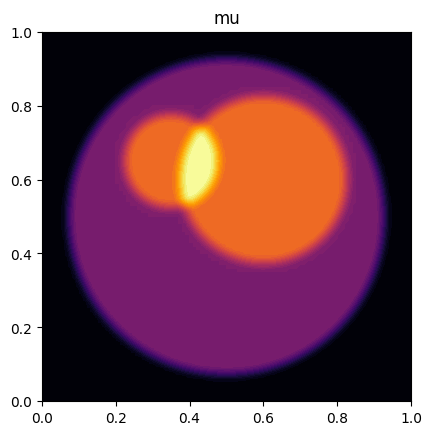

In [3]:
phi_list=[]

class Phi1Expression(df.UserExpression):
    def eval(self, value, x):  
        value[0]=0
        r1= (x[0] - 0.5) *(x[0] - 0.5)  + (x[1] - 0.5) *(x[1] - 0.5)
        if   r1 <= 0.4   *0.4 :
            value[0]= 1
        elif  0.4  *0.4 <= r1<= 0.45  *0.45:
            value[0]=  (1-(math.sqrt(r1) - 0.4)/0.05 )**2*(1+2*(math.sqrt(r1)-0.4) /0.05) 

class Phi2Expression(df.UserExpression):
    def eval(self, value, x):  
        value[0]=0
        r2= (x[0] - 0.35) *(x[0] - 0.35)  + (x[1] - 0.65) *(x[1] - 0.65)
        if  r2 <= 0.1   *0.1 :
            value[0]= 1
        elif  0.1  *0.1<= r2 <= 0.15  *0.15:
            value[0]=  (1-(math.sqrt(r2) - 0.1)/0.05 )**2*(1+2*(math.sqrt(r2)-0.1) /0.05)           

class Phi3Expression(df.UserExpression):
    def eval(self, value, x):  
        value[0]=0
        r3= (x[0] - 0.6) *(x[0] - 0.6)  + (x[1] - 0.6) *(x[1] - 0.6)
        if  r3 <= 0.2   *0.2 :
            value[0]= 1
        elif  0.2  *0.2<= r3 <= 0.25  *0.25:
            value[0]=  (1-(math.sqrt(r3) - 0.2)/0.05 )**2*(1+2*(math.sqrt(r3)-0.2) /0.05) 
phi = Phi1Expression()
phi1=df.interpolate(phi,V_mu)
phi_list.append(phi1)
phi = Phi2Expression()
phi2=df.interpolate(phi,V_mu)
phi_list.append(phi2)
phi = Phi3Expression()
phi3=df.interpolate(phi,V_mu)
phi_list.append(phi3)
a_1, a_2, a_3=1,1,1

mu  = df.project(1+a_1*phi1+ a_2*phi2 + a_3*phi3 , V_mu) 
df.plot(mu, title="mu", cmap="inferno")


### Direct problem

In [4]:
mat_params  = {"mu":mu, "rho":rho, "omega":omega}

ureal, mu_function, ureal_norm = isotropic_elasticity_problem(
    mesh_params=mesh_params,
    mat_params=mat_params,
    load_params=load_params)

Solving linear variational problem.


### PLot u

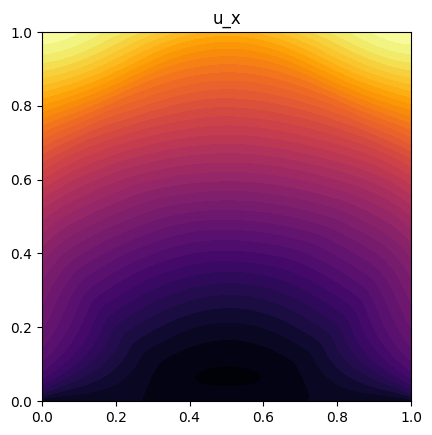

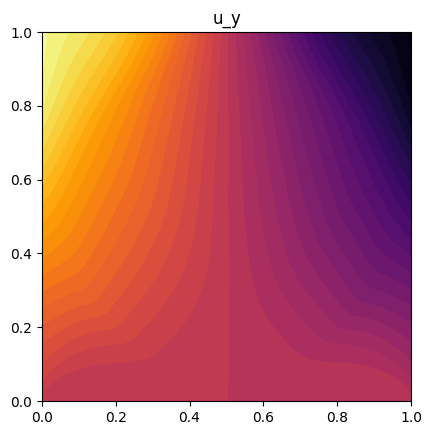

In [5]:
u1, u2 = ureal.split()
df.plot(u1, title="u_x", cmap="inferno")
plt.show()

df.plot(u2, title="u_y", cmap="inferno")
plt.show()

##  Noiseless data

In [6]:
Error_list_Type= []
SNR_list= [0]
V1 = ureal.function_space()
V_mu= mu_function.function_space()
mesh= V_mu.mesh()
dx = df.Measure("dx", domain=mesh)
          

Q= df.FiniteElement('CG', mesh.ufl_cell(), degree=degree - 1)
Q1 = df.FunctionSpace(mesh, Q)
V = df.VectorElement('CG', mesh.ufl_cell(), degree=degree)
V1 = df.FunctionSpace(mesh, V)
V_mu = df.FunctionSpace(mesh, 'CG', degree)

def epsilon(u):
    return 0.5*(df.nabla_grad(u) + df.nabla_grad(u).T) 

### Type 1

In [7]:
alpha=1e6
mu_rec= VFM(phi_list, ureal, V_mu, V, Q, alpha, rho, omega) 
norm1_l2 = math.sqrt(df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
print('L2-norm error, noiseless data :', norm1_l2) 
Error_list_Type.append(norm1_l2*100)

Solving linear variational problem.
Values of m: [0.00024933 0.00047048]
Solving linear variational problem.
Values of m: [1.61575038e-05 8.43490825e-05]
Solving linear variational problem.
Values of m: [7.62984629e-05 2.11087255e-04]
[[4.32848755e-03 2.49334121e-07 4.70480459e-07]
 [1.61575038e-08 2.79562127e-04 8.43490825e-08]
 [7.62984629e-08 2.11087255e-07 7.01118949e-04]]
1.000000000013366
1.0000000000024014
1.0000000000062104
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, noiseless data : 5.992100515137977e-12


## Stability w.r.t. noisy data

In [8]:
Noise_list = np.array( [ 0.025**2, 0.05**2, 0.075**2, 0.10**2, 0.15**2, 0.16**2, 0.18**2, 0.20**2])
nb_noise = np.size(Noise_list)

h=ureal.vector().get_local()
a=h.shape 


In [9]:
for k in range(nb_noise) :  
    print("Noise = ", Noise_list[k])

    class noiseExpression(df.UserExpression):
        def eval(self, value, x):
           value[0]=0
           value[1]=0  
           for m  in range(1,10) :
                value[0] = value[0] +  Noise_list[k]*m/20*math.cos( 2*np.pi*x[0]*m/(20*math.sqrt(abs(Noise_list[k]))) )*math.cos( 2*np.pi*x[1]/(20*math.sqrt(abs( Noise_list[k]))) )*ureal_norm
                value[1] = value[1] + Noise_list[k]*m/20*math.cos( 2*np.pi*x[0]*m/(20*math.sqrt(abs( Noise_list[k]))) )*math.cos( 2*np.pi*x[1]/(20*math.sqrt(abs( Noise_list[k]))) )*ureal_norm
        def value_shape(self):
           return (2,)
    
    noise_Expression= noiseExpression()
    noise_Expression= df.interpolate(noise_Expression, V1) 
    u_noised= df.Function(V1)    
    u_noised.vector()[:] = ureal.vector()[:]+ noise_Expression.vector()[:] 

    SNR = math.sqrt(df.assemble((epsilon(ureal) - epsilon(u_noised))**2 * dx ) + df.assemble((ureal - u_noised)**2 * dx) )/ ureal_norm 
    SNR_list.append(SNR*100)
    print("SNR", SNR)

    mu_rec= VFM(phi_list, u_noised, V_mu, V, Q, alpha, rho, omega) 
    norm1_l2 = math.sqrt(df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
    Error_list_Type.append(norm1_l2*100)
    print(f'L2-norm error, noisy data for SNR ="{SNR}":', norm1_l2)

    

Noise =  0.0006250000000000001
SNR 0.030060523008805545
Solving linear variational problem.
Values of m: [0.00024963 0.00047582]
Solving linear variational problem.
Values of m: [1.61734252e-05 8.40915042e-05]
Solving linear variational problem.
Values of m: [7.76790700e-05 2.11892071e-04]
[[4.33743489e-03 2.49631844e-07 4.75816407e-07]
 [1.61734252e-08 2.80083339e-04 8.40915042e-08]
 [7.76790700e-08 2.11892071e-07 7.07268109e-04]]
0.9917345263582832
1.002938063430965
0.9701572657921204
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, noisy data for SNR ="0.030060523008805545": 0.008095502466332108
Noise =  0.0025000000000000005
SNR 0.06012524300853458
Solving linear variational problem.
Values of m: [0.00024397 0.00048014]
Solving linear variational problem.
Values of m: [1.55198634e-05 8.36086893e-05]
Solving linear variational problem.
Values of m: [7.75200460e-05 2.12199549e-04]
[[4.40414373e-03 2.43968495e-07 4.80138832e-07]
 [1.55198634e-08 2.79229

In [10]:
print("SNR_list=",SNR_list)
print("Error_list_Type=",Error_list_Type)

SNR_list= [0, 3.0060523008805546, 6.012524300853458, 8.396576356443965, 12.036027872170461, 19.48294212690617, 21.71694821679809, 27.035128846710982, 32.95130888190495]
Error_list_Type= [5.992100515137978e-10, 0.8095502466332107, 0.5615041165960785, 1.2942389276995625, 1.415100766338487, 7.59090096463058, 10.26533953650727, 17.17212823683436, 24.66280162730872]


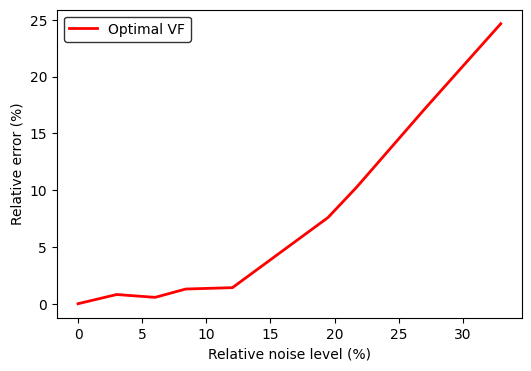

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))   

ax.plot(SNR_list, Error_list_Type, "-r", label="Optimal VF", linewidth=2)

ax.set_xlabel('Relative noise level (%)')
ax.set_ylabel('Relative error (%)')

ax.legend(frameon=True, edgecolor="black", facecolor="white", fontsize=10,
         title_fontsize=10)

plt.show()
